# pyGIMLi(empymod)

v3: try to implement post_step and extract individual inversion results

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pygimli
import empymod

rng = np.random.default_rng(seed=0)

## Create survey, model, and data

In [117]:
# Survey: Offsets and Frequencies
rec_offsets = np.arange(0,300, 7.5)
frequencies = [10, 1000, 10000]

#Resistivity definition
base_res = 35 #Ohmm
anom_res = 20 #Ohmm

# Model depths and resistivities
depth = [0, 110, 190]
mtrue = [2e14, base_res, anom_res, base_res]
m0 = [2e14, base_res, base_res, base_res]

# Collect input parameters
inp = {
    'src': [-200, -180, 0, 0, 0, 0],
    'rec': [rec_offsets*0, rec_offsets*0, rec_offsets, 0, 90],
    'depth': depth,
    'freqtime': frequencies,
    'verb': 1,
}

# Create observed data and background == start model data
dobs = empymod.bipole(res=mtrue, **inp)
d0 = empymod.bipole(res=m0, **inp)
dobs_clean = dobs

### Add noise to `dobs`
=> The following cell should go into `empymod`, or use `emg3d`, where it is already implemented

In [118]:
noise_floor = 1e-15
relative_error = 0.05
mean_noise = 0.0

# Exclude data below half the noise_floor
cut_data = abs(dobs) < (noise_floor / 2)
dobs[cut_data] = np.nan + 1j*np.nan
d0[cut_data] = np.nan + 1j*np.nan

# Add random white noise to dobs
std_dev = np.sqrt(noise_floor**2 + np.abs(relative_error*dobs)**2)
noise = std_dev * ((1+1j)*mean_noise + np.exp(1j * rng.uniform(0, 2*np.pi, dobs.shape)))
dobs += noise

In [119]:
mean_noise = np.mean(np.abs(noise))
print(mean_noise)

1.0823327438189925e-07


(1.5799488481904878e-06-1.1043418219561281e-05j)
(3, 40)
(-1.4367700118452033e-07+1.6326458659960314e-07j)
(1.5799488481904878e-06-1.1043418219561281e-05j)


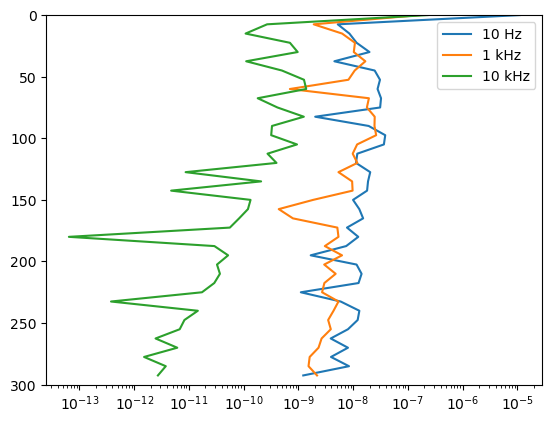

In [120]:
print(noise[0,0])
print(np.shape(noise))
print(np.min(noise))
print(np.max(noise))

plt.plot(abs(np.imag(noise[0])), rec_offsets, label='10 Hz')
plt.plot(abs(np.imag(noise[1])), rec_offsets, label = '1 kHz')
plt.plot(abs(np.imag(noise[2])), rec_offsets, label = '10 kHz')
plt.ylim([300, 0])
#plt.xlim([-4e-8, 4e-8])
plt.xscale('log')
plt.legend()


## QC model and data

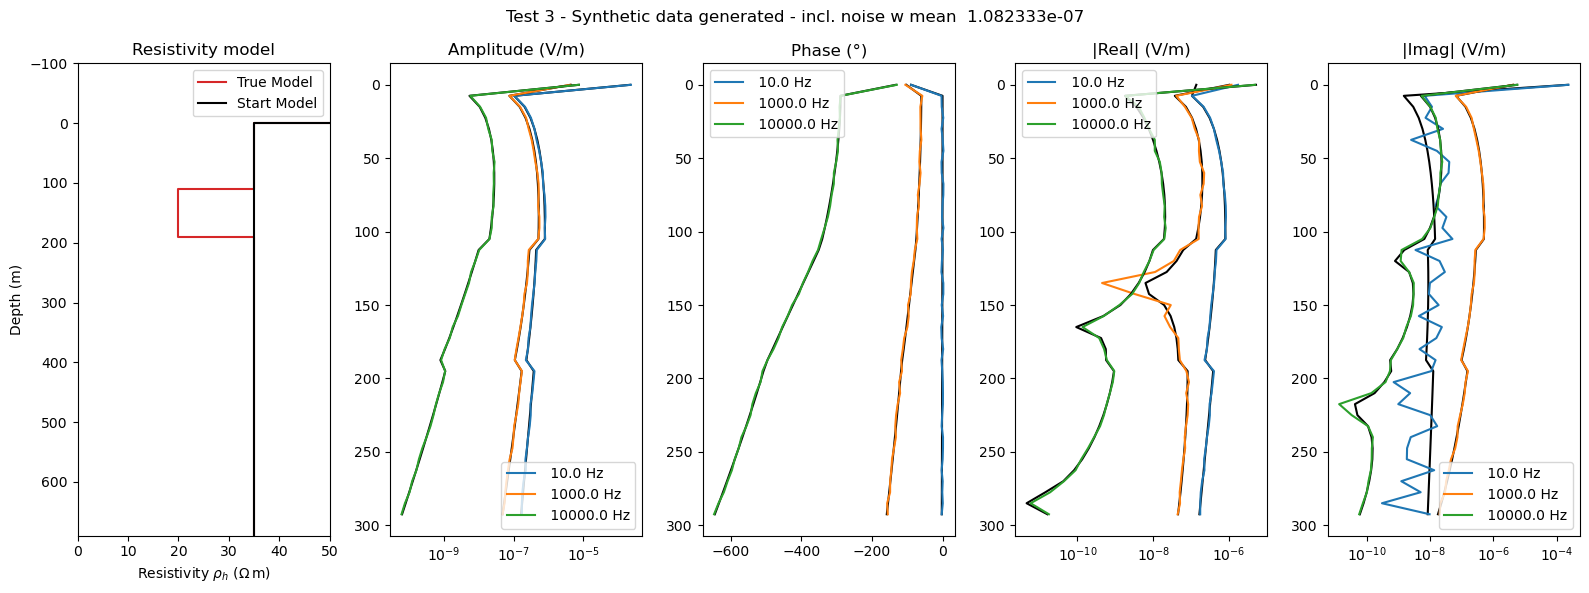

In [121]:
# Plot it
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 6), tight_layout=True)
axes = [ax1, ax2, ax3, ax4, ax5]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-100, np.repeat(depth, 2), 3000]

# Plot Resistivities
ax1.set_title('Resistivity model')
ax1.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax1.plot(p_m0, p_depth, 'k', label="Start Model")
#ax1.set_xscale('log')
ax1.set_xlim([0, 50])
ax1.set_ylim([depth[-1]+500, depth[0]-100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax1.legend()

#Plot measured data
labels = ['Amplitude (V/m)', 'Phase (°)', '|Real| (V/m)', '|Imag| (V/m)']
data_obs = [dobs.amp(), dobs.pha(deg=True), abs(dobs.real), abs(dobs.imag)]
#data_clean = [dobs_clean.amp(), dobs_clean.pha(deg=True), abs(dobs_clean.real), abs(dobs_clean.imag)]
data0 = [(dobs-noise).amp(), (dobs-noise).pha(deg=True), abs((dobs-noise).real), abs((dobs-noise).imag)]
#data00 = [d0.amp(), d0.pha(deg=True), abs(d0.real), abs(d0.imag)]
fig.suptitle("Test 3 - Synthetic data generated - incl. noise w mean "+f"{mean_noise: 3e}")
for j in np.arange(len(labels)):
    ax = axes[j+1]
    ax.set_title(labels[j])
    for i, f in enumerate(frequencies):
        ax.plot(data0[j][i,:], rec_offsets, 'k')
        #ax.plot(data00[j][:], rec_offsets)
        ax.plot(data_obs[j][i,:], rec_offsets, label=f"{f: 2.1f} Hz")  
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.legend()
    #ax.set_xlim([-1e-7, 1e-7])

ax3.set_xscale('linear')

## Study the errors

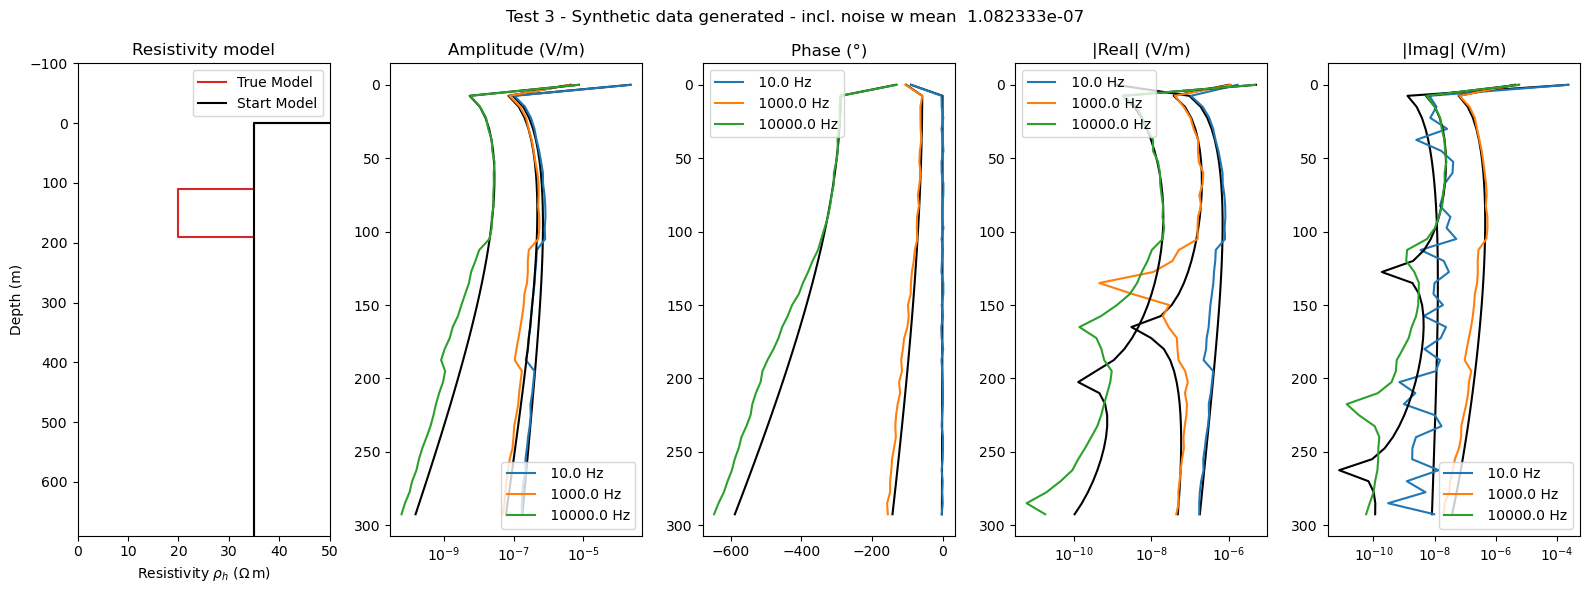

In [122]:
# Plot it
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 6), tight_layout=True)
axes = [ax1, ax2, ax3, ax4, ax5]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-100, np.repeat(depth, 2), 3000]

# Plot Resistivities
ax1.set_title('Resistivity model')
ax1.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax1.plot(p_m0, p_depth, 'k', label="Start Model")
#ax1.set_xscale('log')
ax1.set_xlim([0, 50])
ax1.set_ylim([depth[-1]+500, depth[0]-100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax1.legend()

#Plot measured data
labels = ['Amplitude (V/m)', 'Phase (°)', '|Real| (V/m)', '|Imag| (V/m)']
data_obs = [dobs.amp(), dobs.pha(deg=True), abs(dobs.real), abs(dobs.imag)]
data0 = [d0.amp(), d0.pha(deg=True), abs(d0.real), abs(d0.imag)]
fig.suptitle("Test 3 - Synthetic data generated - incl. noise w mean "+f"{mean_noise: 3e}")
for j in np.arange(len(labels)):
    ax = axes[j+1]
    ax.set_title(labels[j])
    for i, f in enumerate(frequencies):
        ax.plot(data0[j][i,:], rec_offsets, 'k')
        ax.plot(data_obs[j][i,:], rec_offsets, label=f"{f: 2.1f} Hz")  
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.legend()

ax3.set_xscale('linear')

## Forward Kernel and modified Inversion class
=> The following cell should go into `empymod.inv.pygimli`

In [123]:
class Kernel(pygimli.Modelling):
    
    def __init__(self, input_map, routine=empymod.bipole):
        """Initialize the model."""
        super().__init__()

        # Store inputs
        self.input_map = input_map
        self.routine = routine
        
    def response(self, x):
        """Forward response.""" 
        #print('problem 0')   

        # Compute responses
        em = self.routine(**self.input_map(x))
        
        # Ravel output, taking care of complex values
        em = np.r_[em.ravel().real, em.ravel().imag if np.iscomplexobj(em) else []]

        # Return required data
        return em if not hasattr(self, 'indices') else em[self.indices]
    
    def createStartModel(self, dataVals=None):
        """Overwrite default method with an Error.""" 
        raise NotImplementedError("Start Model must be provided.")

class Inversion(pygimli.Inversion):
    
    def run(self, dataVals, errorVals=None, **kwargs):

        # Store the mesh (pseudo)
        if "startModel" in kwargs:
            n_model = len(np.atleast_1d(kwargs["startModel"]))
        else:
            n_model = len(self.startModel)
        self.fop.mesh1d = pygimli.meshtools.createMesh1D(n_model)
        self.fop.setMesh(self.fop.mesh1d)

        # Error: Same as in original function, but taking care of complex data
        if errorVals is None:  # use absoluteError and/or relativeError instead
            absErr = kwargs.pop("absoluteError", 0)
            relErr = kwargs.pop("relativeError",
                                0.01 if np.allclose(absErr, 0) else 0)
            errorVals = abs(absErr / np.asarray(abs(dataVals))) + relErr

        if isinstance(errorVals, (float, int)):
            errorVals = np.ones_like(dataVals.real) * errorVals
        
        # Ravel data and decompose complex data
        d_size = dataVals.size
        d_shape = dataVals.shape
        is_complex = False
        if np.iscomplexobj(dataVals):
            is_complex = True
            d_size *= 2
        dataVals = np.r_[dataVals.ravel().real, dataVals.ravel().imag if is_complex else []]
        errorVals = np.r_[errorVals.ravel(), errorVals.ravel() if is_complex else []]

        # Limit to finite values
        if np.any(~np.isfinite(dataVals)):
            self.fop.indices = np.isfinite(dataVals)
            dataVals = dataVals[self.fop.indices]
            errorVals = errorVals[self.fop.indices]

        # Run the inversion
        model = super().run(dataVals=dataVals, errorVals=errorVals, **kwargs)

        # Reshape data           
        if hasattr(self.fop, 'indices'):
            out = np.ones(d_size)*np.nan
            out[self.fop.indices] = np.array(self.response)
        else:
            out = np.array(self.response)
        if is_complex:
            out = out[:d_size//2] + 1j*out[d_size//2:]               
        response = empymod.EMArray(np.reshape(out, d_shape))

        # Return mapped parameters and response
        return self.fop.input_map(model), response
    
    

## Inversion

Note that the objective function is calculated like:

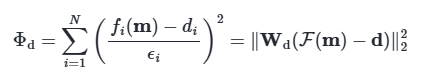

with f_i(m) the modelled data (forward response at the data point), d_i the data, eps_i the error, N the amount of data points. An expression in terms of W_d is derived with W_d being a data weighting matrix containing the inverse data errors and F(m) the forward model response vector.

Once the objective function is determined, we determine the gradient. This is done using Gauss-Newtonian method in our case, which works by solving the following formula using a least-squares solver:

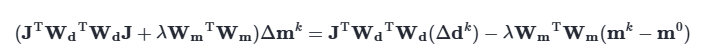

This allows us to find delta-m which indicates the direction of the model update. **But it should be noted that a transformation by scalar tau is needed to determine the actual step increase.** This is found in PyGIMLi by doing a line search.

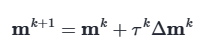



In [124]:
%%time

def input_map(x, inp=inp):
    """Map the inversion parameter to modelling parameters."""
    # Could be res, aniso, depth, a mixture of it, ...
    inp['res'] =  np.r_[2e14, x]
    return inp

fop = Kernel(input_map, empymod.bipole)
inv = Inversion(fop=fop)

# Not Sure Yet How To Use These
#inv.dataTrans = pygimli.trans.TransSymLog(1e-20)
#inv.transModel = pygimli.trans.TransLog(0.1) # > 1 Ohmm

#inv.modelTrans = 'log'

out, response = inv.run(
    dataVals=dobs,
    absoluteError=std_dev,
    #relativeError=0.01,
    startModel=m0[1:],
    verbose = True,
    dPhi=2,
    #max_iter = 30,
    #lam=2000000
)
# Get inversion result from parameter dict
# Could be res, aniso, depth, ...
minv = out['res']

25/06/26 - 16:43:53 - pyGIMLi - INFO - Starting inversion.


fop: <__main__.Kernel object at 0x00000216032660C0>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): -2.3e-04/1.7e-06
min/max (error): 4.76%/5.26%
min/max (start model): 35/35
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 70704.62
--------------------------------------------------------------------------------
inv.iter 1 ... chi² = 4519.96 (dPhi = 93.61%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² = 2351.07 (dPhi = 47.98%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² = 2126.58 (dPhi = 9.55%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² = 1974.54 (dPhi = 7.15%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 5 ... chi² = 1878.89 (dPh

In [125]:
print(inv.lam)

20


In [126]:
phi_delta_history = []

for i in np.arange(1, len(phi_data_history)):
    phi_delta_history.append((phi_data_history[i]-phi_data_history[i-1])/phi_data_history[i-1])

print(phi_data_history)
print(phi_delta_history)

[12632921.24378582, 4399283.212138685, 3648257.621969298, 2287377.271014157, 1511333.2511692112, 1206250.6561317411, 1126063.8766283414, 1093391.2226503638, 1129505.766252359]
[-0.6517604180978561, -0.1707154447563472, -0.37302199898387367, -0.3392724189747983, -0.20186321898327148, -0.06647605047573306, -0.02901492060628566, 0.0330298459086346]


In [127]:
model_history = inv.modelHistory
chi2_history = inv.chi2History
phi_history = []
phi_data_history = []
for i in np.arange(len(model_history)):
    phi_history.append(inv.phi(response=i))
    phi_data_history.append(inv.phiData(response=fop.response(model_history[i])))
print(model_history)
print(chi2_history)
print(phi_history)
print(phi_data_history)

[[35, 35, 35], 3 [30.953711125869077, 29.698258806207786, 31.087807656360656], 3 [31.073419220748836, 27.37067370722293, 26.647043682080916], 3 [30.986181323779117, 29.470018453478072, 19.720029194604955], 3 [30.949323531429393, 31.866938307260472, 14.021815954412308], 3 [32.12325255244869, 30.141387768372915, 10.932245604004237], 3 [34.8587976276992, 26.712294075602966, 6.051317467673165], 3 [39.28696305663366, 22.205132951697873, 1.914490757115248], 3 [40.28155468579888, 21.894728201289926, 0.7246821196993359], 3 [40.78725247783507, 21.83730604315831, 0.35222943113345706], 3 [40.823405762663555, 21.956825306973716, 0.2578079965612114]]
[70704.62132179337, 4519.963494891561, 2351.065522219172, 2126.5815233621947, 1974.5393274211451, 1878.889165373624, 1635.600448790717, 1336.028096373332, 1109.787844561478, 1026.3074541674964, 1013.3607302513835]
[96896.56210022679, 1.631006343332724e+25, 6.5240253733480835e+25, 1.4679057090046095e+26, 2.609610149342676e+26, 4.077515858349001e+26, 5.8

In [128]:
#pygimli.viewer.show(model_history[0])
print(model_history[0])

[35, 35, 35]


Iteration 0: Model = [35 35 35]
Jacobian = [ 1.51e-08 -1.10e-08 -1.20e-08]
Iteration 1: Model = [30.95 29.7  31.09]
Jacobian = [ 3.71e-09 -7.30e-10 -7.23e-10]
Iteration 2: Model = [31.07 27.37 26.65]
Jacobian = [ 7.36e-09 -1.46e-09 -1.45e-09]
Iteration 3: Model = [30.99 29.47 19.72]
Jacobian = [ 1.09e-08 -2.18e-09 -2.18e-09]
Iteration 4: Model = [30.95 31.87 14.02]
Jacobian = [ 1.42e-08 -2.90e-09 -2.93e-09]
Iteration 5: Model = [32.12 30.14 10.93]
Jacobian = [ 1.73e-08 -3.60e-09 -3.69e-09]
Iteration 6: Model = [34.86 26.71  6.05]
Jacobian = [ 2.02e-08 -4.29e-09 -4.47e-09]
Iteration 7: Model = [39.29 22.21  1.91]
Jacobian = [ 2.28e-08 -4.96e-09 -5.27e-09]
Iteration 8: Model = [40.28 21.89  0.72]
Jacobian = [ 2.50e-08 -5.59e-09 -6.10e-09]
Iteration 9: Model = [40.79 21.84  0.35]
Jacobian = [ 2.70e-08 -6.19e-09 -6.96e-09]
Iteration 10: Model = [40.82 21.96  0.26]
Jacobian = [ 2.86e-08 -6.74e-09 -7.85e-09]
[-93.60725874717559, -47.984855964515326, -9.54818131334285, -7.149605800235959, -4.

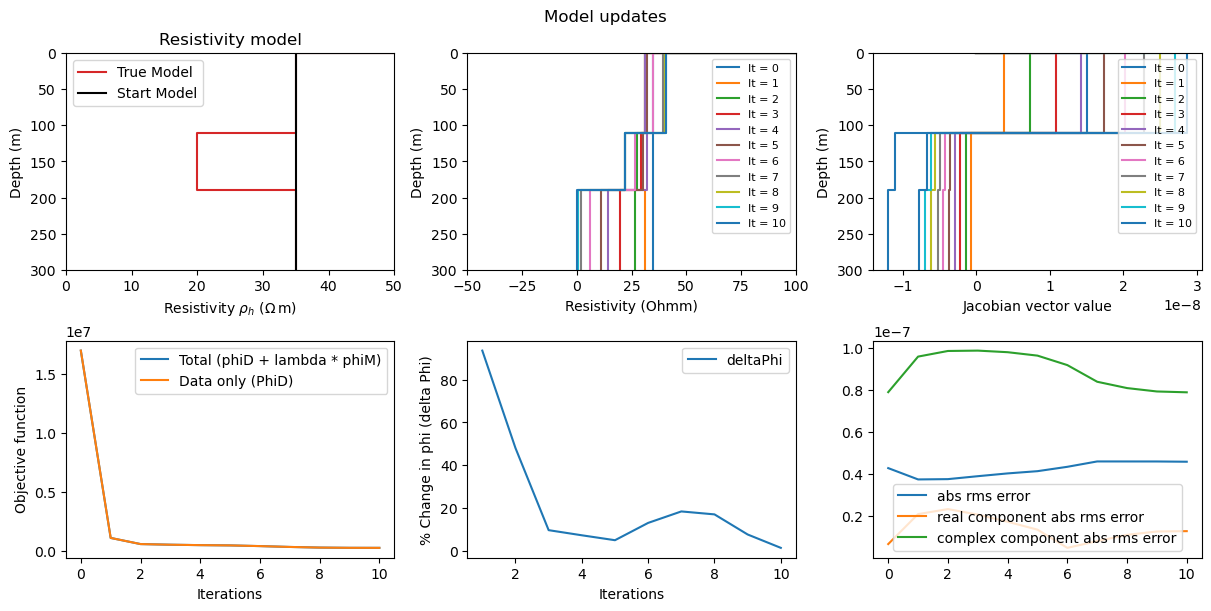

In [129]:
fig, ((ax0, ax1, ax2), (ax3, ax4, ax5)) = plt.subplots(2,3, figsize=(12,6), constrained_layout=True)
fig.suptitle('Model updates')
ax1.set_xlabel('Resistivity (Ohmm)')
ax1.set_ylabel('Depth (m)')
ax2.set_xlabel('Jacobian vector value')
ax2.set_ylabel('Depth (m)')
ax3.set_xlabel('Iterations')
ax3.set_ylabel('Objective function')
ax4.set_xlabel('Iterations')
ax4.set_ylabel('% Change in phi (delta Phi)')

ax0.set_title('Resistivity model')
ax0.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax0.plot(p_m0, p_depth, 'k', label="Start Model")
#ax1.set_xscale('log')
ax0.set_xlim([0, 50])
ax0.set_ylim([300, 0])
ax0.set_ylabel('Depth (m)')
ax0.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax0.legend()

np.set_printoptions(precision=2)

jacobians = np.array(inv.fop.jacobian())
phi_history = []
phi_data_history = []
phi_delta_history = []
absrms_history = []
absrms_real_history = []
absrms_complex_history = []
relrms_history = []

dobs_gimli = np.r_[dobs.ravel().real, dobs.ravel().imag]

for i, model in enumerate(inv.modelHistory):
    data = np.array(fop.response(model_history[i]))
    model_to_plot = np.concatenate([[2e14], np.repeat(model,2)])
    jac_to_plot = np.concatenate([[0], np.repeat(jacobians[i],2)])
    phi_history.append(inv.phi(response=data))
    phi_data_history.append(inv.phiData(response=data))
    absrms_history.append(np.sqrt(np.mean(dobs_gimli-data)**2))
    absrms_real_history.append(np.sqrt(np.mean(dobs_gimli[:int(len(data)/2)]-data[:int(len(data)/2)])**2))
    absrms_complex_history.append(np.sqrt(np.mean(dobs_gimli[int(len(data)/2):]-data[int(len(data)/2):])**2))
    ax1.plot(model_to_plot, np.concatenate([np.repeat(depth,2), [500]]), label='It = '+str(i))
    ax2.plot(jac_to_plot, np.concatenate([np.repeat(depth,2), [500]]), label='It = '+str(i))
    print(f"Iteration {i}: Model = {np.array(model)}")
    print(f"Jacobian = {np.array(jacobians[i], dtype=float)}")

for i in np.arange(1, len(phi_data_history)):
    phi_delta_history.append((phi_data_history[i]-phi_data_history[i-1])/phi_data_history[i-1]*100)

ax3.plot(np.arange(len(phi_history)), phi_history, label = 'Total (phiD + lambda * phiM)')
ax3.plot(np.arange(len(phi_history)), phi_data_history, label = 'Data only (PhiD)')
ax4.plot(np.arange(1,len(phi_history)), np.abs(phi_delta_history), label = 'deltaPhi')
ax5.plot(np.arange(len(phi_history)), absrms_history, label = 'abs rms error')
ax5.plot(np.arange(len(phi_history)), absrms_real_history, label = 'real component abs rms error')
ax5.plot(np.arange(len(phi_history)), absrms_complex_history, label = 'complex component abs rms error')

print(phi_delta_history)
ax1.set_ylim([300,0])
ax2.set_ylim([300, 0])
#ax.set_xscale('log')
ax1.set_xlim([-50, 100])
ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
ax3.legend()
ax4.legend()
ax5.legend()

## Plot results

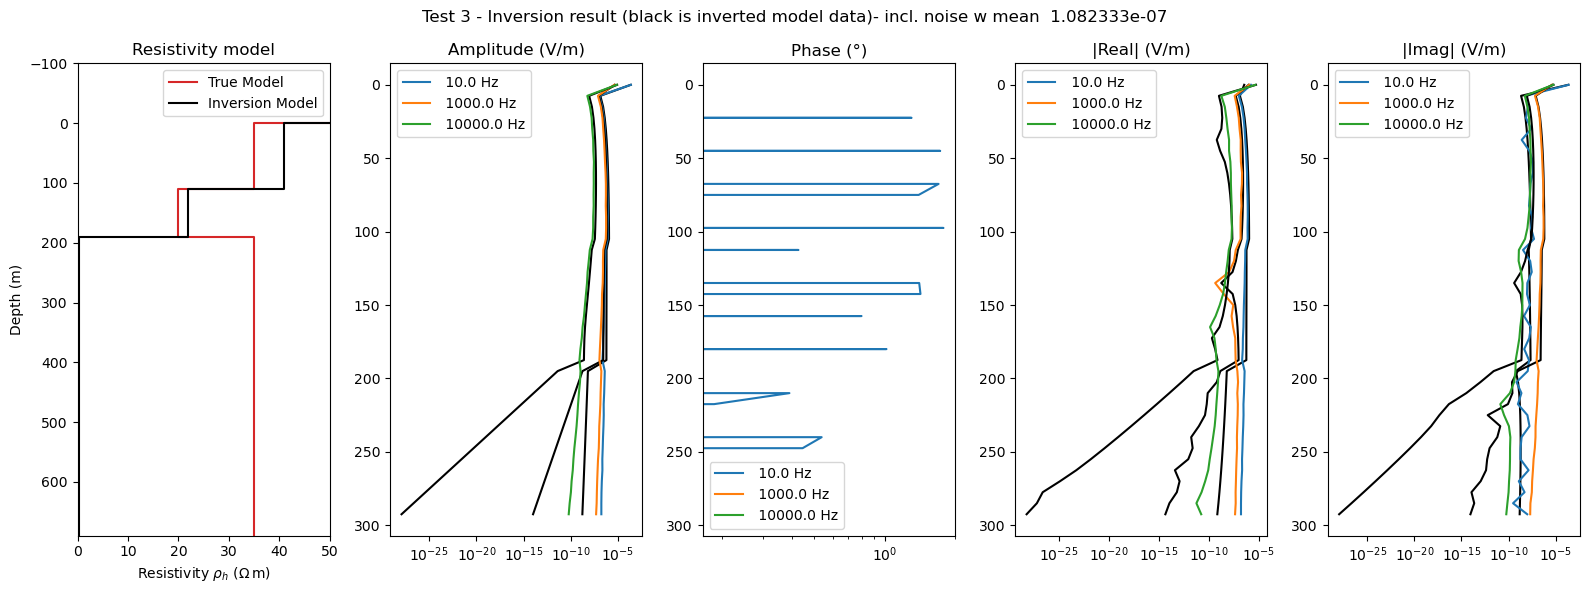

In [130]:
# Plot it
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 6), tight_layout=True)
axes = [ax1, ax2, ax3, ax4, ax5]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-100, np.repeat(depth, 2), 3000]
p_minv = np.repeat(minv, 2)

# Plot Resistivities
ax1.set_title('Resistivity model')
ax1.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax1.plot(p_minv, p_depth, 'k', label="Inversion Model")
#ax1.set_xscale('log')
ax1.set_xlim([0, 50])
ax1.set_ylim([depth[-1]+500, depth[0]-100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax1.legend()

#Plot measured data
labels = ['Amplitude (V/m)', 'Phase (°)', '|Real| (V/m)', '|Imag| (V/m)']
data_obs = [dobs.amp(), dobs.pha(deg=True), abs(dobs.real), abs(dobs.imag)]
data_inv = [response.amp(), response.pha(deg=True), abs(response.real), abs(response.imag)]
fig.suptitle("Test 3 - Inversion result (black is inverted model data)- incl. noise w mean "+f"{mean_noise: 3e}")
for j in np.arange(len(labels)):
    ax = axes[j+1]
    ax.set_title(labels[j])
    for i, f in enumerate(frequencies):
        ax.plot(data_inv[j][i,:], rec_offsets, 'k')
        ax.plot(data_obs[j][i,:], rec_offsets, label=f"{f: 2.1f} Hz")
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.legend()

In [8]:
empymod.Report(['pyGIMLi', 'pgcore'])

--------------------------------------------------------------------------------
  Date: Mon Jun 01 11:50:33 2026 UTC

                OS : Windows (10 10.0.26100 SP0 Multiprocessor Free)
            CPU(s) : 14
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.4 GiB
       Environment : Jupyter

  Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00)
  [MSC v.1944 64 bit (AMD64)]

           pyGIMLi : 1.5.5
            pgcore : 1.5.0
             numpy : 1.26.4
             scipy : 1.14.1
             numba : 0.65.1
           empymod : 2.5.4
            libdlf : 0.3.0
           IPython : 9.10.0
        matplotlib : 3.10.9
--------------------------------------------------------------------------------

In [ ]:
def __init__(self, fop=None, inv=None, **kwargs):
        """Initialize an Inversion instance."""
        super().__init__(fop=fop, inv=inv, **kwargs)
        self._postStep = _post_step

def _post_step(n, inv):
        """Print some values for each iteration. Written for use with emg3d now adapted to use with empymod.
        https://github.com/emsig/emg3d/blob/inv-pygimli/emg3d/inversion/pygimli.py#L294-L297"""
        #sim = inv.fop.simulation

        # Print info
        phi = inv.inv.getPhi()
        if n == 0:
            pygimli.info(
                f"{75*'='}\n{39*' '}"
                " it   F(m)         χ²          λ         ϕᵈ         ϕᵐ"
                f"   ϕ=ϕᵈ+λϕᵐ   Δϕ (%)\n{39*' '}{75*'-'}"
            )
            deltaphi = 0
            #sim.invinfo = {}

        else:
            deltaphi = (1-phi/inv.lastphi)*100
        inv.lastphi = phi
        pygimli.info(
            f"{n:3d}"
            f"{_multiprocessing.process_map.count:7d} "
            f"{_round_format(inv.inv.chi2())} "
            f"{_round_format(inv.inv.getLambda())} "
            f"{_round_format(inv.inv.getPhiD())} "
            f"{_round_format(inv.inv.getPhiM())} "
            f"{_round_format(phi)}"
            f"{deltaphi:9.2f}"
        )

        # Store data TODO store everything required to reproduce or restart inv
        #sim.survey.data[f"it{n}"] = sim.survey.data.synthetic
        # TODO store data and model as gimli vectors; requires region info
        #model = inv.fop.simulation.model.copy()
        model = inv._start
        model.property_x = inv.fop.model2emg3d(inv.model)
        sim.invinfo[n] = {
            'model': model,
            'chi2': inv.inv.chi2(),
            'phi': phi,
            'phi_d': inv.inv.getPhiD(),
            'phi_m': inv.inv.getPhiM(),
            'phi_delta': deltaphi,
            'count': _multiprocessing.process_map.count,
            'lambda': inv.inv.getLambda(),
            'time': sim.timer.elapsed,
        }
        if sim.name:
            io.save(
                f"{sim.name}.h5",
                simulation=sim.to_dict(what='plain'),
                invinfo=sim.invinfo,
                verb=0,
            )

        # Reset counter
        _multiprocessing.process_map.count = 0